# Final Evaluation

Run after  training models


In [10]:
from pathlib import Path
import networkx as nx
import pandas as pd
import numpy as np

FOLDER = Path('./asnr datasets')
assert FOLDER.exists(), f"Dataset folder not found: {FOLDER}"

asnr_graphs: dict[str, nx.Graph] = {}
for fp in FOLDER.glob('*.graphml'):
    asnr_graphs[fp.stem + '.graphml'] = nx.read_graphml(fp)

info_frame = pd.read_csv(FOLDER / 'Network_summary_masterfile.csv')

selected_classes = ['Mammalia', 'Insecta', 'Aves']
selected_interactions = [
    'physical_contact',
    'social_projection_bipartite',
    'spatial_proximity',
    'grooming',
    'dominance',
    'FE_mating',
]

filtered_df = (
    info_frame[
        info_frame['interaction_type'].isin(selected_interactions) &
        info_frame['class'].isin(selected_classes) &
        (info_frame['nodes'] > 5) &
        pd.notna(info_frame['avg.edge.strength'])
    ]
    .copy()
    .rename(columns={'class': 'network_class'})
    .reset_index(drop=True)
)

interaction_mapping = {c: i for i, c in enumerate(selected_interactions)}
bio_class_mapping   = {c: i for i, c in enumerate(selected_classes)}
filtered_df['interaction_map'] = filtered_df['interaction_type'].map(interaction_mapping)

bio_inv         = {v: k for k, v in bio_class_mapping.items()}
interaction_inv = {v: k for k, v in interaction_mapping.items()}
bio_names       = [bio_inv[i] for i in sorted(bio_inv)]

print(f"Loaded {len(asnr_graphs)} graphs | Filtered: {len(filtered_df)}")


Loaded 1197 graphs | Filtered: 924


In [11]:
import copy, random, torch
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data

def build_dataset(graphs_dict, df_subset):
    dataset = []
    for _, row in df_subset.iterrows():
        key = row['Network_ID']
        if key not in graphs_dict:
            continue
        G = graphs_dict[key]
        G = G.to_undirected() if G.is_directed() else G
        node_mapping = {node: i for i, node in enumerate(G.nodes())}
        clustering   = nx.clustering(G)
        x = torch.tensor(
            [[G.degree(n), clustering[n]] for n in G.nodes()], dtype=torch.float)
        edges = []
        for u, v in G.edges():
            edges += [[node_mapping[u], node_mapping[v]],
                      [node_mapping[v], node_mapping[u]]]
        if not edges:
            continue
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        data            = Data(x=x, edge_index=edge_index,
                               y=torch.tensor([row['interaction_map']], dtype=torch.long))
        data.bio_class  = torch.tensor(
            [bio_class_mapping.get(row['network_class'], -1)], dtype=torch.long)
        data.network_id = key
        dataset.append(data)
    return dataset

def augment_node_drop(data, drop_prob=0.05):
    data_aug  = copy.deepcopy(data)
    num_nodes = data_aug.num_nodes
    if num_nodes <= 5:
        return None
    keep_mask = torch.tensor(
        [random.random() > drop_prob for _ in range(num_nodes)], dtype=torch.bool)
    if keep_mask.sum() < 5:
        return None
    data_aug.x = data_aug.x[keep_mask]
    ei        = data_aug.edge_index
    edge_mask = keep_mask[ei[0]] & keep_mask[ei[1]]
    ei        = ei[:, edge_mask]
    old_to_new = torch.full((num_nodes,), -1, dtype=torch.long)
    old_to_new[keep_mask] = torch.arange(keep_mask.sum())
    data_aug.edge_index = old_to_new[ei]
    return data_aug

def oversample_minority(dataset, df, target_col='interaction_map',
                        copies_per_graph=20, drop_prob=0.08, seed=124):
    random.seed(seed); torch.manual_seed(seed)
    counts         = df[target_col].value_counts()
    majority_count = counts.max()
    augmented      = list(dataset)
    for data in dataset:
        label = data.y.item()
        if counts[label] < majority_count * 5:
            for _ in range(copies_per_graph):
                aug = augment_node_drop(data, drop_prob=drop_prob)
                if aug is not None:
                    augmented.append(aug)
                    counts[label] += 1
    return augmented

train_val_df, test_df = train_test_split(
    filtered_df, test_size=0.15,
    stratify=filtered_df['interaction_map'], random_state=42)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.15/0.85,
    stratify=train_val_df['interaction_map'], random_state=42)

train_dataset   = build_dataset(asnr_graphs, train_df)
val_dataset     = build_dataset(asnr_graphs, val_df)
test_dataset    = build_dataset(asnr_graphs, test_df)
augmented_train = oversample_minority(train_dataset, train_df)

print(f"Train: {len(train_dataset)} ({len(augmented_train)} augmented) "
      f"| Val: {len(val_dataset)} | Test: {len(test_dataset)}")


Train: 646 (5507 augmented) | Val: 139 | Test: 139


In [12]:
import torch.nn.functional as F
from torch import nn
from torch_geometric.nn import GCNConv, global_mean_pool

class GCNClassifier(nn.Module):
    def __init__(self, in_channels=2, hidden_dim=64, num_classes=6, dropout=0.3):
        super().__init__()
        self.conv1      = GCNConv(in_channels, hidden_dim)
        self.conv2      = GCNConv(hidden_dim,  hidden_dim)
        self.conv3      = GCNConv(hidden_dim,  hidden_dim)
        self.dropout    = dropout
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def encode(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv3(x, edge_index))
        return global_mean_pool(x, batch)

    def forward(self, data):
        return self.classifier(self.encode(data.x, data.edge_index, data.batch))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


Device: cpu


In [13]:
# Load Models
import torch
from torch_geometric.loader import DataLoader

model = GCNClassifier(in_channels=2, hidden_dim=64,
                      num_classes=len(selected_interactions)).to(device)
model.load_state_dict(torch.load('interaction_model.pt', map_location=device))
model.eval()

bio_model = GCNClassifier(in_channels=2, hidden_dim=64,
                          num_classes=len(selected_classes)).to(device)
bio_model.load_state_dict(torch.load('bio_model.pt', map_location=device))
bio_model.eval()

test_loader = DataLoader(test_dataset, batch_size=32)
print("Models loaded")


Models loaded


## Helpers

In [14]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

def run_inference(mdl, loader):
    preds, int_true, bio_true, ids = [], [], [], []
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            preds.extend(mdl(data).argmax(dim=1).cpu().tolist())
            int_true.extend(data.y.cpu().tolist())
            bio_true.extend(data.bio_class.cpu().tolist())
            ids.extend(data.network_id)
    return np.array(preds), np.array(int_true), np.array(bio_true), ids

def add_confusion_matrix(ax, y_true, y_pred, class_names, fmt):
    """Draw a single confusion matrix panel onto ax."""
    cm = confusion_matrix(y_true, y_pred)
    if fmt == '.2f':
        #Row Normalized
        data = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    else:
        data = cm

    im = ax.imshow(data, cmap='Blues', vmin=0, vmax=data.max())
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(class_names, fontsize=9)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            val = data[i, j]
            ax.text(j, i, format(val, fmt),
                    ha='center', va='center', fontsize=12, fontweight='bold',
                    color='white' if val > data.max() * 0.6 else 'black')
    return im


## Interaction type model

In [15]:
int_pred, int_true, int_bio, net_ids = run_inference(model, test_loader)
print(classification_report(int_true, int_pred,
                             target_names=selected_interactions, zero_division=0))


                             precision    recall  f1-score   support

           physical_contact       0.89      0.98      0.93        41
social_projection_bipartite       0.72      0.65      0.68        43
          spatial_proximity       0.43      0.26      0.32        23
                   grooming       0.45      0.53      0.49        17
                  dominance       0.38      0.38      0.38         8
                  FE_mating       0.54      1.00      0.70         7

                   accuracy                           0.67       139
                  macro avg       0.57      0.63      0.58       139
               weighted avg       0.66      0.67      0.66       139



## Biological class model

In [16]:
bio_pred, _, bio_true, _ = run_inference(bio_model, test_loader)
print(classification_report(bio_true, bio_pred,
                             target_names=bio_names, zero_division=0))

              precision    recall  f1-score   support

    Mammalia       0.89      0.77      0.83        77
     Insecta       0.88      1.00      0.94        38
        Aves       0.57      0.71      0.63        24

    accuracy                           0.82       139
   macro avg       0.78      0.82      0.80       139
weighted avg       0.83      0.82      0.82       139



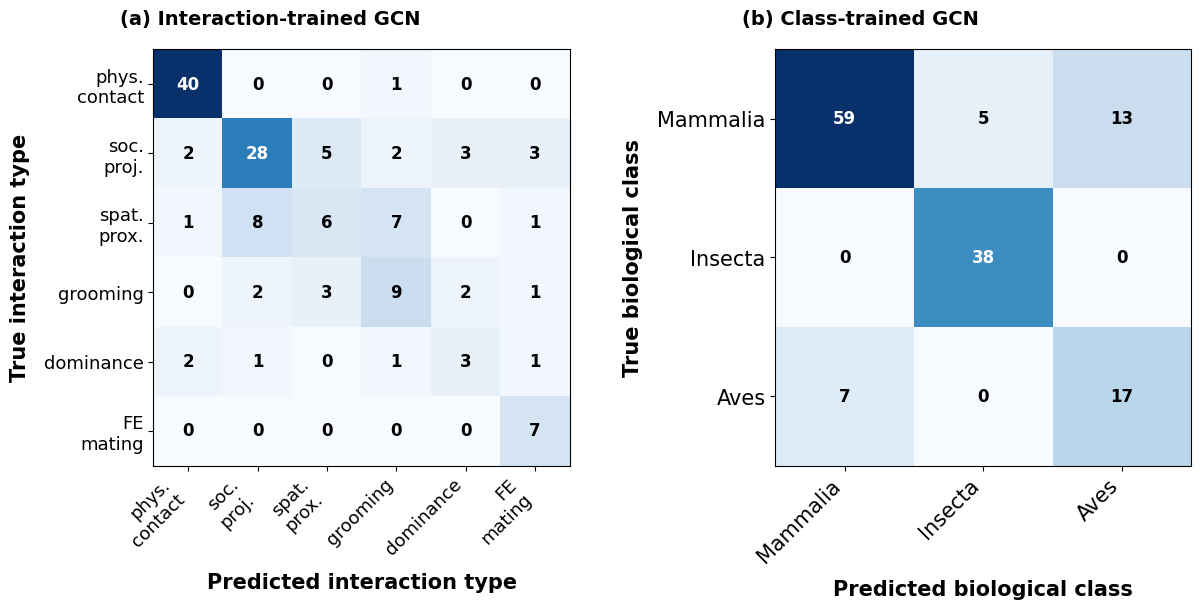

In [ ]:
# Short labels for the 6-class interaction matrix
int_short_labels = ['phys.\ncontact', 'soc.\nproj.', 'spat.\nprox.',
                    'grooming', 'dominance', 'FE\nmating']

fig, axes = plt.subplots(1, 2, figsize=(12.5, 6))


im0 = add_confusion_matrix(
    axes[0], int_true, int_pred, int_short_labels,
    fmt='d',
)
axes[0].set_xlabel('Predicted interaction type', fontsize=15, labelpad=10, fontweight='bold')
axes[0].set_ylabel('True interaction type',      fontsize=15, labelpad=10, fontweight='bold')
axes[0].tick_params(axis='both', labelsize=13)

#cbar0 = plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.06)
#cbar0.set_label('Recall', fontsize=11)
#cbar0.ax.tick_params(labelsize=10)


im1 = add_confusion_matrix(
    axes[1], bio_true, bio_pred, bio_names,
    fmt='d',
)
axes[1].set_xlabel('Predicted biological class', fontsize=15, labelpad=10, fontweight='bold')
axes[1].set_ylabel('True biological class',      fontsize=15, labelpad=10, fontweight='bold')
axes[1].tick_params(axis='both', labelsize=15)

#cbar1 = plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.06)
#cbar1.set_label('Recall', fontsize=11)
#cbar1.ax.tick_params(labelsize=10)


axes[0].text(-0.08, 1.05, '(a) Interaction-trained GCN', transform=axes[0].transAxes,
             fontsize=14, fontweight='bold', va='bottom')
axes[1].text(-0.08, 1.05, '(b) Class-trained GCN', transform=axes[1].transAxes,
             fontsize=14, fontweight='bold', va='bottom')

plt.tight_layout()
plt.savefig('confusion_matrices_combined.pdf', bbox_inches='tight', dpi=300)
plt.show()

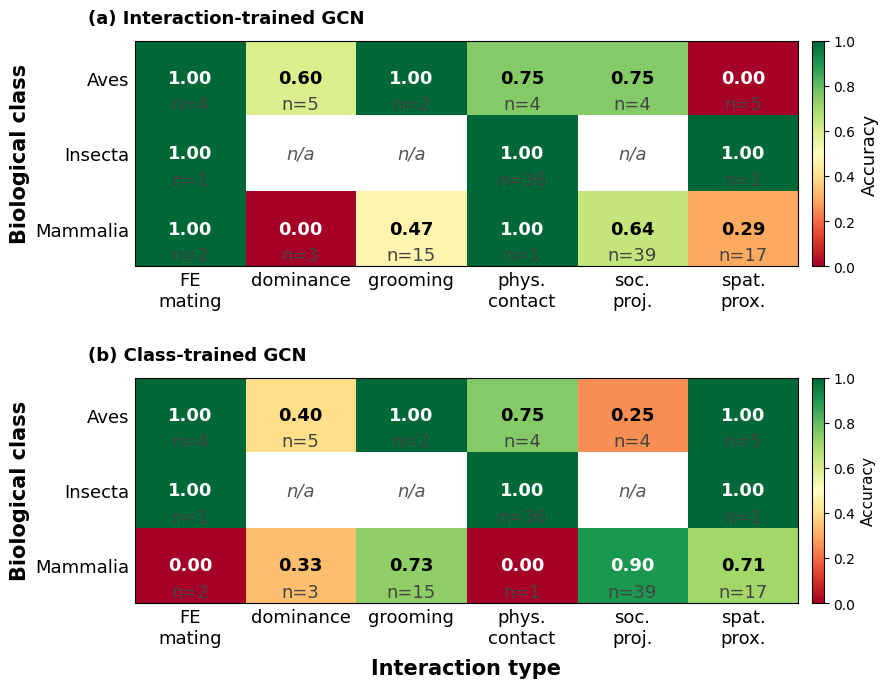

In [18]:
# Set Up New Frames
int_results_df = pd.DataFrame({
    'network_id':       net_ids,
    'true_interaction': [interaction_inv[i] for i in int_true],
    'bio_class':        [bio_inv.get(i, 'Unknown') for i in int_bio],
    'correct':          int_pred == int_true,
})
bio_results_df = pd.DataFrame({
    'network_id':       net_ids,
    'true_interaction': [interaction_inv[i] for i in int_true],
    'bio_class':        [bio_inv.get(i, 'Unknown') for i in int_bio],
    'correct':          bio_pred == bio_true,
})

# Short interaction type labels for compact display
int_short = {
    'physical_contact':            'phys.\ncontact',
    'social_projection_bipartite': 'soc.\nproj.',
    'spatial_proximity':           'spat.\nprox.',
    'grooming':                    'grooming',
    'dominance':                   'dominance',
    'FE_mating':                   'FE\nmating',
}
int_results_df['interaction_label'] = int_results_df['true_interaction'].map(int_short)
bio_results_df['interaction_label'] = bio_results_df['true_interaction'].map(int_short)

# Heatmap
def plot_accuracy_heatmap(ax, df, index_col, col_col, panel_label):
    acc_pivot   = df.pivot_table(index=index_col, columns=col_col,
                                  values='correct', aggfunc='mean')
    count_pivot = df.pivot_table(index=index_col, columns=col_col,
                                  values='correct', aggfunc='count')

    im = ax.imshow(acc_pivot.values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

    ax.set_xticks(range(len(acc_pivot.columns)))
    ax.set_yticks(range(len(acc_pivot.index)))
    ax.set_xticklabels(acc_pivot.columns, rotation=0, ha='center', fontsize=13)
    ax.set_yticklabels(acc_pivot.index,   fontsize=13)
    ax.tick_params(axis='both', length=0)

    # Panel label 
    ax.text(-0.07, 1.06, panel_label, transform=ax.transAxes,
            fontsize=13, fontweight='bold', va='bottom')

    # Cell annotations: accuracy value only (n in parentheses, smaller)
    for i in range(len(acc_pivot.index)):
        for j in range(len(acc_pivot.columns)):
            val = acc_pivot.values[i, j]
            n   = count_pivot.values[i, j]
            if np.isnan(val):
                ax.text(j, i, 'n/a', ha='center', va='center',
                        fontsize=13, color='#555555', style='italic')
            else:
                # Accuracy on top, sample size smaller below
                ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                        fontsize=13, fontweight='bold',
                        color='white' if val < 0.25 or val > 0.80 else 'black')
                ax.text(j, i + 0.35, f'n={int(n)}', ha='center', va='center',
                        fontsize=13, color='#444444')
    return im

fig, axes = plt.subplots(2, 1, figsize=(9, 7))

im0 = plot_accuracy_heatmap(
    axes[0], int_results_df,
    index_col='bio_class', col_col='interaction_label',
    panel_label='(a) Interaction-trained GCN',
)
axes[0].set_xlabel('')
axes[0].set_ylabel('Biological class', fontsize=15, fontweight='bold')
cbar0 = plt.colorbar(im0, ax=axes[0], fraction=0.03, pad=0.02)
cbar0.set_label('Accuracy', fontsize=13)
cbar0.ax.tick_params(labelsize=10)

im1 = plot_accuracy_heatmap(
    axes[1], bio_results_df,
    index_col='bio_class', col_col='interaction_label',
    panel_label='(b) Class-trained GCN',
)
axes[1].set_xlabel('Interaction type', fontsize=15, labelpad=8, fontweight='bold')
axes[1].set_ylabel('Biological class', fontsize=15, fontweight='bold')
cbar1 = plt.colorbar(im1, ax=axes[1], fraction=0.03, pad=0.02)
cbar1.set_label('Accuracy', fontsize=11)
cbar1.ax.tick_params(labelsize=10)

plt.tight_layout(h_pad=2.5)
plt.savefig('bio_class_accuracy_heatmap.pdf', bbox_inches='tight', dpi=300)
plt.show()